Number of common sequences: 6
Number of unique ACP sequences: 855
Number of unique CPP sequences: 1192
Common Sequences: 
KLAKLAKKLAKLAK
GRKKRRQRRR
RKKRRQRRR
RQIKIWFQNRRMKWKK
GIGKFLHSAKKWGKAFVGQIMNC
YKQCHKKGGHCFPKEKICLPPSSDFGKMDCRWRWKCCKKGSG


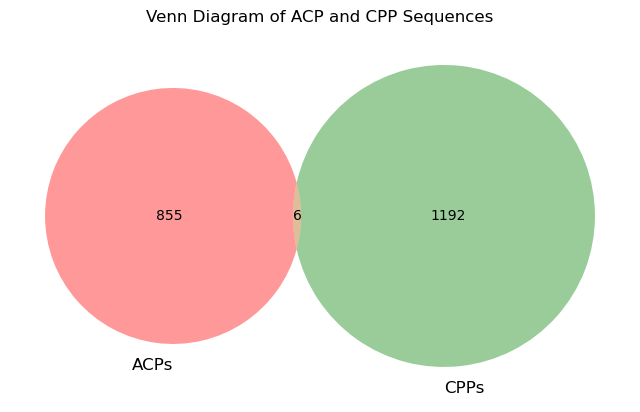

In [2]:


from Bio import SeqIO
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

def compare_fasta_files(acp_fasta_file, cpp_fasta_file):
    """
    Compares two FASTA files (ACPs and CPPs) to find common sequences and plots a Venn diagram.

    Args:
        acp_fasta_file (str): Path to the ACP FASTA file.
        cpp_fasta_file (str): Path to the CPP FASTA file.

    Returns:
        tuple: A tuple containing two sets:
            - common_sequences (set): Sequences present in both FASTA files.
            - unique_sequences (dict): A dictionary with keys "acp" and "cpp", 
                                       containing sets of sequences unique to each file.
    """

    acp_sequences = set()
    cpp_sequences = set()

    try:
        for record in SeqIO.parse(acp_fasta_file, "fasta"):
            acp_sequences.add(str(record.seq))  # Convert Seq object to string
        for record in SeqIO.parse(cpp_fasta_file, "fasta"):
            cpp_sequences.add(str(record.seq))  # Convert Seq object to string
    except FileNotFoundError:
        print("Error: One or both FASTA files not found.")
        return None

    common_sequences = acp_sequences.intersection(cpp_sequences)
    unique_sequences = {"acp": acp_sequences - common_sequences, 
                        "cpp": cpp_sequences - common_sequences}

    return common_sequences, unique_sequences


def plot_venn_diagram(common_sequences, unique_sequences):
    """Plots a Venn diagram of the common and unique sequences."""

    plt.figure(figsize=(8, 6))
    venn = venn2(subsets=(len(unique_sequences["acp"]), len(unique_sequences["cpp"]), len(common_sequences)), 
              set_labels=('ACPs', 'CPPs'))
    plt.title("Venn Diagram of ACP and CPP Sequences")

    # Annotate the Venn diagram with counts (optional)
    venn.get_label_by_id('10').set_text(str(len(unique_sequences["acp"])))  # ACP only
    venn.get_label_by_id('01').set_text(str(len(unique_sequences["cpp"])))  # CPP only
    venn.get_label_by_id('11').set_text(str(len(common_sequences)))       # Common

    plt.show()


# Example usage:
acp_file = "ACP_TRAIN.fasta"  # Replace with your ACP FASTA file path
cpp_file = "natural_pep_cpp.txt"  # Replace with your CPP FASTA file path

comparison_result = compare_fasta_files(acp_file, cpp_file)

if comparison_result:
    common, unique = comparison_result
    print(f"Number of common sequences: {len(common)}")
    print(f"Number of unique ACP sequences: {len(unique['acp'])}")
    print(f"Number of unique CPP sequences: {len(unique['cpp'])}")

    if common: #If there are common sequence print them 
      print("Common Sequences: ")
      for seq in common:
        print(seq)

    plot_venn_diagram(common, unique)